# LUCIE Inference

> **NOTE**
> Please see the [LUCIE Training](./LUCIE-Training.ipynb) tutorial to train the model weights required for this tutorial
> 

In [1]:
import torch
import lucie
import lucie.inference
from pathlib import Path
import numpy as np
import xarray as xr

In [2]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
device = torch.device("cuda:0" if torch.cuda.is_available() else device)

In [3]:
regridded_path = Path.home() / 'dev/data/lucie' / 'era5_T30_regridded.npz'
regridded_data = lucie.train.load_data(regridded_path)

In [4]:
preprocessed_path = Path.home() / 'dev/data/lucie' / 'era5_T30_preprocessed.npz'
preprocessed_data = np.load(preprocessed_path)

In [5]:
%%time
%%capture

# Note - these timings were obtained on a laptop, not on a high-performance GPU.

predictions = lucie.inference.load_data_and_predict(device, regridded_data, preprocessed_data,model_weights_pth='model.pth')

CPU times: user 1min 49s, sys: 30.3 s, total: 2min 19s
Wall time: 1min 54s


In [6]:
da = xr.DataArray(predictions)

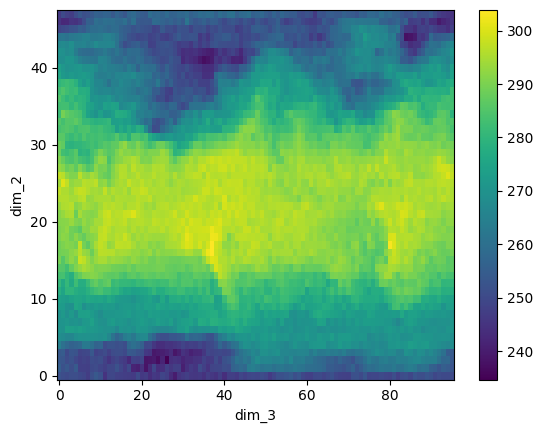

In [7]:
# Please note - this image was generated from only a few samples of training and does not represent the final model
da[5][0].plot()